# HAM10000 — Clasificación con fuentes sintéticas aisladas

Evalúa el efecto de cada fuente sintética por separado, controlando la cantidad (N=801 en escenarios `_2x`).

| Escenario | Train mel | Fuente sintética | Pregunta |
|---|---|---|---|
| `img2img_2x` | 801 real + 801 img2img | img2img | ¿img2img es mejor que mezcla? |
| `ti_filtered_2x` | 801 real + 801 TI filtradas | TI (solo calidad OK) | ¿Filtrar TI mejora? |
| `gan64_2x` | 801 real + 801 GAN-64px | WGAN-GP 64×64 | ¿La resolución importa? |
| `img2img_all` | 801 real + 2403 img2img | img2img (todo) | ¿Más img2img ayuda? |
| `img2img_only` | 0 real + 801 img2img | img2img | ¿img2img reemplaza reales? |

Los 3 escenarios `_2x` usan la misma N — solo cambia la fuente. Permite aislar el efecto de la fuente.

**Prerequisitos Colab:**
- `classification_data.zip` en Drive: `Mi unidad/ham10000-augmentation/`
- Carpetas sintéticas en Drive: `synthetic/textual_inversion/` y `synthetic/img2img/`
- ZIP del GAN en Drive: `Mi unidad/ham10000-augmentation/gan_generated.zip`

In [10]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import torch

def get_device():
    if torch.cuda.is_available():
        name = torch.cuda.get_device_name(0)
        vram = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f'CUDA GPU: {name}  ({vram:.1f} GB)')
        return torch.device('cuda'), vram
    if torch.backends.mps.is_available():
        print('Apple Silicon MPS')
        return torch.device('mps'), 0
    print('Sin GPU — usando CPU')
    return torch.device('cpu'), 0

DEVICE, VRAM_GB = get_device()
print(f'IN_COLAB={IN_COLAB}  device={DEVICE}')

CUDA GPU: Tesla T4  (15.6 GB)
IN_COLAB=True  device=cuda


In [11]:
from pathlib import Path

if IN_COLAB:
    drive.mount('/content/drive')
    DRIVE_ROOT  = Path('/content/drive/MyDrive/ham10000-augmentation')
    ZIP_PATH    = DRIVE_ROOT / 'classification_data.zip'
    IMAGES_DIR  = Path('/content/images')
    SPLITS_DIR  = Path('/content/splits')
    SYNTH_ROOT  = DRIVE_ROOT / 'synthetic'
    GAN_ZIP     = next(DRIVE_ROOT.glob('gan_generated*.zip'), None)
    GAN_64_DIR  = Path('/content/gan_64')
    EXP_ROOT    = DRIVE_ROOT / 'experiments'
else:
    PROJECT_ROOT = Path.cwd()
    ZIP_PATH     = PROJECT_ROOT / 'data/processed/classification_data.zip'
    IMAGES_DIR   = PROJECT_ROOT / 'data/processed/images'
    SPLITS_DIR   = PROJECT_ROOT / 'data/processed/splits'
    SYNTH_ROOT   = PROJECT_ROOT / 'data/synthetic'
    GAN_ZIP      = next(PROJECT_ROOT.glob('gan_generated*.zip'), None)
    GAN_64_DIR   = PROJECT_ROOT / 'data/synthetic/gan_64'
    EXP_ROOT     = PROJECT_ROOT / 'experiments'

EXP_ROOT.mkdir(parents=True, exist_ok=True)
print(f'Imágenes:   {IMAGES_DIR}')
print(f'Sintéticas: {SYNTH_ROOT}')
print(f'GAN ZIP:    {GAN_ZIP}')
print(f'GAN-64 dir: {GAN_64_DIR}')
print(f'Experimentos: {EXP_ROOT}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Imágenes:   /content/images
Sintéticas: /content/drive/MyDrive/ham10000-augmentation/synthetic
GAN ZIP:    /content/drive/MyDrive/ham10000-augmentation/gan_generated.zip
GAN-64 dir: /content/gan_64
Experimentos: /content/drive/MyDrive/ham10000-augmentation/experiments


In [12]:
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

try:
    import timm; print(f'timm {timm.__version__}')
except ImportError:
    pip_install('timm'); import timm

try:
    import sklearn; print(f'scikit-learn {sklearn.__version__}')
except ImportError:
    pip_install('scikit-learn'); import sklearn

try:
    import cv2; print(f'cv2 {cv2.__version__}')
except ImportError:
    pip_install('opencv-python-headless'); import cv2

print('Dependencias listas')

timm 1.0.26
scikit-learn 1.6.1
cv2 4.13.0
Dependencias listas


In [13]:
# Extraer ZIP de imágenes reales (solo Colab, idempotente)
import zipfile

if IN_COLAB:
    IMAGES_DIR.mkdir(parents=True, exist_ok=True)
    SPLITS_DIR.mkdir(parents=True, exist_ok=True)
    jpg_count = len(list(IMAGES_DIR.glob('*.jpg')))
    if jpg_count < 100:
        assert ZIP_PATH.exists(), f'ZIP no encontrado: {ZIP_PATH}'
        print('Extrayendo imágenes reales del ZIP...')
        with zipfile.ZipFile(ZIP_PATH) as zf:
            for m in zf.infolist():
                data = zf.read(m.filename)
                if m.filename.startswith('images/') and m.filename.endswith('.jpg'):
                    (IMAGES_DIR / Path(m.filename).name).write_bytes(data)
                elif m.filename.startswith('splits/') and m.filename.endswith('.csv'):
                    (SPLITS_DIR / Path(m.filename).name).write_bytes(data)
        print('Listo')
    else:
        print(f'Imágenes ya extraídas ({jpg_count} archivos)')

Imágenes ya extraídas (7818 archivos)


In [14]:
# Copiar sintéticas de Drive a disco local (solo Colab, una vez por sesión)
import shutil

if IN_COLAB:
    LOCAL_SYNTH = Path('/content/synthetic')
    if not LOCAL_SYNTH.exists():
        print('Copiando sintéticas de Drive a /content/synthetic/ ...')
        shutil.copytree(str(SYNTH_ROOT), str(LOCAL_SYNTH))
        print(f'Listo: {len(list(LOCAL_SYNTH.glob("**/*.jpg")))} imágenes')
    else:
        print(f'Sintéticas ya en local: {len(list(LOCAL_SYNTH.glob("**/*.jpg")))} imágenes')
    SYNTH_ROOT = LOCAL_SYNTH

Sintéticas ya en local: 6903 imágenes


In [15]:
# Extraer imágenes GAN-64 del ZIP (solo Colab, idempotente)
import struct

if IN_COLAB:
    GAN_64_DIR.mkdir(parents=True, exist_ok=True)
    n_existing = len(list(GAN_64_DIR.glob('*.png')))
    if n_existing < 10:
        assert GAN_ZIP and GAN_ZIP.exists(), (
            f'ZIP del GAN no encontrado en Drive.\n'
            f'Sube el archivo como: Mi unidad/ham10000-augmentation/gan_generated.zip'
        )
        print(f'Extrayendo imágenes GAN-64 de {GAN_ZIP.name}...')
        with zipfile.ZipFile(GAN_ZIP) as zf:
            for member in zf.infolist():
                if not member.filename.endswith('.png'):
                    continue
                data = zf.read(member.filename)
                w = struct.unpack('>I', data[16:20])[0]
                h = struct.unpack('>I', data[20:24])[0]
                if w == 64 and h == 64:
                    (GAN_64_DIR / Path(member.filename).name).write_bytes(data)
        n = len(list(GAN_64_DIR.glob('*.png')))
        print(f'Listo: {n} imágenes GAN-64')
    else:
        print(f'GAN-64 ya extraído: {n_existing} imágenes')
else:
    n = len(list(GAN_64_DIR.glob('*.png'))) if GAN_64_DIR.exists() else 0
    print(f'GAN-64 local: {n} imágenes en {GAN_64_DIR}')

Extrayendo imágenes GAN-64 de gan_generated.zip...
Listo: 1000 imágenes GAN-64


## Estado de escenarios
Ejecuta esta celda para ver el progreso sin cargar modelos.

In [17]:
import json

SCENARIOS = ['img2img_2x', 'ti_filtered_2x', 'gan64_2x', 'img2img_all', 'img2img_only']

def find_run_dir(sc):
    pointer = EXP_ROOT / f'{sc}_current.txt'
    if pointer.exists():
        return EXP_ROOT / pointer.read_text().strip()
    completed = sorted([d for d in EXP_ROOT.glob(f'*_{sc}') if (d / 'test_metrics.json').exists()])
    return completed[-1] if completed else None

print('Estado de escenarios:')
for sc in SCENARIOS:
    run_dir = find_run_dir(sc)
    if run_dir is None:
        print(f'  {sc}: pendiente')
    elif (run_dir / 'test_metrics.json').exists():
        m = json.loads((run_dir / 'test_metrics.json').read_text())
        print(f'  {sc}: completado ({run_dir.name})  AUC={m["auc"]}  Recall_mel={m["recall_mel"]}  F1_mel={m["f1_mel"]}')
    else:
        ckpt = run_dir / 'checkpoint_last.pt'
        status = 'retomable (checkpoint existe)' if ckpt.exists() else 'iniciado'
        print(f'  {sc}: {status} ({run_dir.name})')

ti_paths  = list((SYNTH_ROOT / 'textual_inversion').glob('*.jpg')) if (SYNTH_ROOT / 'textual_inversion').exists() else []
i2i_paths = list((SYNTH_ROOT / 'img2img').glob('*.jpg')) if (SYNTH_ROOT / 'img2img').exists() else []
gan_paths = list(GAN_64_DIR.glob('*.png')) if GAN_64_DIR.exists() else []
print(f'\nFuentes disponibles — TI: {len(ti_paths)}  img2img: {len(i2i_paths)}  GAN-64: {len(gan_paths)}')

Estado de escenarios:
  img2img_2x: pendiente
  ti_filtered_2x: pendiente
  gan64_2x: pendiente
  img2img_all: pendiente
  img2img_only: pendiente

Fuentes disponibles — TI: 4500  img2img: 2403  GAN-64: 1000


## Hiperparámetros

In [18]:
EPOCHS = 15
LR     = 1e-4
SEED   = 42

if DEVICE.type == 'cuda':
    BATCH_SIZE  = 64 if VRAM_GB >= 40 else 32
    NUM_WORKERS = 2
else:
    BATCH_SIZE  = 8
    NUM_WORKERS = 0

import random
import numpy as np

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

print(f'EPOCHS={EPOCHS}  LR={LR}  BATCH_SIZE={BATCH_SIZE}  NUM_WORKERS={NUM_WORKERS}')

EPOCHS=15  LR=0.0001  BATCH_SIZE=32  NUM_WORKERS=2


## Utilidades de dataset y filtro de calidad

In [19]:
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

TRAIN_TF = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
EVAL_TF = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class FlatDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

    def class_weights(self):
        labels  = np.array([l for _, l in self.samples])
        counts  = np.bincount(labels)
        w_class = 1.0 / counts.astype(float)
        return torch.tensor([w_class[l] for _, l in self.samples], dtype=torch.float)


def make_loader(samples, transform, weighted=False):
    ds  = FlatDataset(samples, transform)
    pin = DEVICE.type == 'cuda'
    if weighted:
        sampler = WeightedRandomSampler(ds.class_weights(), len(ds), replacement=True)
        return DataLoader(ds, batch_size=BATCH_SIZE, sampler=sampler,
                         num_workers=NUM_WORKERS, pin_memory=pin)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                     num_workers=NUM_WORKERS, pin_memory=pin)


def resolve_path(rel_path):
    if IN_COLAB:
        return IMAGES_DIR / Path(rel_path).name
    return Path.cwd() / rel_path


def load_splits():
    def read(csv_path, label_filter=None):
        df = pd.read_csv(csv_path)
        if label_filter is not None:
            df = df[df['label'] == label_filter]
        return [(resolve_path(row['image_path']), int(row['label'])) for _, row in df.iterrows()]

    train_nv  = read(SPLITS_DIR / 'train.csv', label_filter=0)
    train_mel = read(SPLITS_DIR / 'train.csv', label_filter=1)
    val       = read(SPLITS_DIR / 'val.csv')
    test      = read(SPLITS_DIR / 'test.csv')
    print(f'Splits — train nv:{len(train_nv)} mel:{len(train_mel)} | val:{len(val)} | test:{len(test)}')
    return train_nv, train_mel, val, test


# --- Filtro de calidad (mismo criterio que HAM10000_quality_evaluation.ipynb) ---
def passes_quality_filter(img_path: Path) -> bool:
    """True si la imagen pasa el filtro mínimo de calidad visual."""
    try:
        img = np.array(Image.open(img_path).convert('RGB').resize((224, 224)))
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        mean_v   = float(hsv[:, :, 2].mean())
        std_rgb  = float(img.std(axis=(0, 1)).mean())
        h, s, v  = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]
        skin_ratio = float(((( h <= 25) | (h >= 150)) & (s > 20) & (v > 20)).mean())
        return (20 < mean_v < 235) and (std_rgb >= 8) and (skin_ratio >= 0.02)
    except Exception:
        return False


def get_filtered_ti(cache_path: Path, seed: int = SEED):
    """Lista reproducible de paths TI que pasan el filtro. Cachea en cache_path."""
    if cache_path.exists():
        paths = [Path(p) for p in json.loads(cache_path.read_text())]
        print(f'TI filtradas (cache): {len(paths)} imágenes')
        return paths
    all_ti = sorted((SYNTH_ROOT / 'textual_inversion').glob('*.jpg'))
    print(f'Aplicando filtro de calidad a {len(all_ti)} imágenes TI...')
    filtered = [p for p in all_ti if passes_quality_filter(p)]
    random.Random(seed).shuffle(filtered)
    cache_path.write_text(json.dumps([str(p) for p in filtered]))
    print(f'TI filtradas: {len(filtered)}/{len(all_ti)} ({100*len(filtered)/len(all_ti):.1f}%)')
    return filtered


def synth_samples_from(paths, n=None, seed=SEED):
    """(Path, 1) list desde una lista de paths, orden reproducible."""
    paths = list(paths)
    random.Random(seed).shuffle(paths)
    if n is not None:
        paths = paths[:n]
    return [(p, 1) for p in paths]


print('Utilidades de dataset listas')

Utilidades de dataset listas


## Loop de entrenamiento con resume

In [20]:
import time
import timm
import torch.nn as nn
from datetime import datetime, timezone
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.auto import tqdm
from sklearn.metrics import (
    f1_score, roc_auc_score, recall_score,
    classification_report, confusion_matrix, roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt


def build_model():
    return timm.create_model('efficientnet_b0', pretrained=True, num_classes=2)


def _eval_loop(model, loader, criterion):
    model.eval()
    loss_sum, total = 0.0, 0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            probs  = torch.softmax(logits, dim=1)[:, 1]
            loss_sum += loss.item() * len(labels)
            total    += len(labels)
            all_preds.extend(logits.argmax(1).cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            all_probs.extend(probs.cpu().tolist())
    return {
        'loss':       round(loss_sum / total, 4),
        'f1_mel':     round(f1_score(all_labels, all_preds, pos_label=1, zero_division=0), 4),
        'recall_mel': round(recall_score(all_labels, all_preds, pos_label=1, zero_division=0), 4),
        'auc':        round(roc_auc_score(all_labels, all_probs), 4),
    }


def run_scenario(name, train_samples, val_samples, test_samples):
    pointer_file = EXP_ROOT / f'{name}_current.txt'
    if pointer_file.exists():
        run_id = pointer_file.read_text().strip()
    else:
        run_id = f'{datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")}_{name}'
        pointer_file.write_text(run_id)

    run_dir     = EXP_ROOT / run_id
    run_dir.mkdir(parents=True, exist_ok=True)
    done_marker = run_dir / 'test_metrics.json'
    ckpt_path   = run_dir / 'checkpoint_last.pt'

    if done_marker.exists():
        metrics = json.loads(done_marker.read_text())
        pointer_file.unlink(missing_ok=True)
        print(f'[{name}] Ya completado ({run_id})')
        print(f'  AUC={metrics["auc"]}  Recall_mel={metrics["recall_mel"]}  F1_mel={metrics["f1_mel"]}')
        return metrics

    n_nv  = sum(1 for _, l in train_samples if l == 0)
    n_mel = sum(1 for _, l in train_samples if l == 1)
    print(f'\n{"="*60}')
    print(f'Escenario: {name} ({run_id})')
    print(f'train nv={n_nv} mel={n_mel}  |  val={len(val_samples)} test={len(test_samples)}')
    print(f'{"="*60}')

    if not (run_dir / 'config.json').exists():
        config = {
            'run_id': run_id, 'scenario': name, 'model': 'efficientnet_b0',
            'pretrained': True, 'epochs': EPOCHS, 'batch_size': BATCH_SIZE,
            'lr': LR, 'seed': SEED, 'train_nv': n_nv, 'train_mel': n_mel,
            'started_at': datetime.now(timezone.utc).isoformat(),
        }
        (run_dir / 'config.json').write_text(json.dumps(config, indent=2))

    train_loader = make_loader(train_samples, TRAIN_TF, weighted=True)
    val_loader   = make_loader(val_samples,   EVAL_TF)
    test_loader  = make_loader(test_samples,  EVAL_TF)

    model     = build_model().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

    start_epoch = 1
    best_f1     = 0.0
    history     = []

    if ckpt_path.exists():
        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['optimizer'])
        scheduler.load_state_dict(ckpt['scheduler'])
        start_epoch = ckpt['epoch'] + 1
        best_f1     = ckpt['best_f1']
        history     = ckpt['history']
        print(f'Retomando desde epoch {start_epoch}  (best_f1={best_f1:.4f})')

    for epoch in range(start_epoch, EPOCHS + 1):
        t0 = time.time()
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f'[{name}] Epoch {epoch:02d}/{EPOCHS}', leave=False)
        for imgs, labels in pbar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(labels)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += len(labels)
            pbar.set_postfix(loss=f'{loss.item():.4f}', acc=f'{correct/total:.3f}')

        scheduler.step()
        val_m   = _eval_loop(model, val_loader, criterion)
        elapsed = time.time() - t0

        row = {'epoch': epoch, 'train_loss': round(train_loss/total, 4),
               'train_acc': round(correct/total, 4),
               **{f'val_{k}': v for k, v in val_m.items()},
               'elapsed_s': round(elapsed, 1)}
        history.append(row)
        print(f'  Epoch {epoch:02d}/{EPOCHS} | loss={train_loss/total:.4f} | '
              f'val_f1_mel={val_m["f1_mel"]:.3f} val_auc={val_m["auc"]:.3f} | {elapsed:.0f}s')

        if val_m['f1_mel'] >= best_f1:
            best_f1 = val_m['f1_mel']
            torch.save(model.state_dict(), run_dir / 'best_model.pt')

        torch.save({
            'epoch': epoch, 'model': model.state_dict(),
            'optimizer': optimizer.state_dict(), 'scheduler': scheduler.state_dict(),
            'best_f1': best_f1, 'history': history,
        }, ckpt_path)

    (run_dir / 'history.json').write_text(json.dumps(history, indent=2))

    model.load_state_dict(torch.load(run_dir / 'best_model.pt', map_location=DEVICE))
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            logits = model(imgs.to(DEVICE))
            probs  = torch.softmax(logits, dim=1)[:, 1]
            all_preds.extend(logits.argmax(1).cpu().tolist())
            all_labels.extend(labels.tolist())
            all_probs.extend(probs.cpu().tolist())

    report = classification_report(all_labels, all_preds, target_names=['nv', 'mel'], output_dict=True)
    auc    = roc_auc_score(all_labels, all_probs)

    metrics = {
        'auc':           round(auc, 4),
        'f1_mel':        round(report['mel']['f1-score'], 4),
        'recall_mel':    round(report['mel']['recall'], 4),
        'precision_mel': round(report['mel']['precision'], 4),
        'f1_nv':         round(report['nv']['f1-score'], 4),
        'accuracy':      round(report['accuracy'], 4),
    }
    done_marker.write_text(json.dumps(metrics, indent=2))
    (run_dir / 'classification_report.json').write_text(json.dumps(report, indent=2))

    cfg = json.loads((run_dir / 'config.json').read_text())
    cfg['finished_at']  = datetime.now(timezone.utc).isoformat()
    cfg['test_metrics'] = metrics
    (run_dir / 'config.json').write_text(json.dumps(cfg, indent=2))

    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=['nv', 'mel']).plot(ax=ax, colorbar=False)
    ax.set_title(f'Confusion Matrix — {name}')
    fig.tight_layout(); fig.savefig(run_dir / 'confusion_matrix.png', dpi=150); plt.close(fig)

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'ROC — {name}'); ax.legend()
    fig.tight_layout(); fig.savefig(run_dir / 'roc_curve.png', dpi=150); plt.close(fig)

    ckpt_path.unlink(missing_ok=True)
    pointer_file.unlink(missing_ok=True)

    print(f'\n[{name}] COMPLETADO  AUC={metrics["auc"]}  Recall_mel={metrics["recall_mel"]}  F1_mel={metrics["f1_mel"]}')
    return metrics


print('Loop de entrenamiento listo')

Loop de entrenamiento listo


## Cargar splits y preparar fuentes sintéticas

In [21]:
train_nv, train_mel, val_samples, test_samples = load_splits()

n_2x = len(train_mel)  # 801 — N de control para escenarios aislados

# Fuentes disponibles
i2i_paths = sorted((SYNTH_ROOT / 'img2img').glob('*.jpg'))
gan_paths  = sorted(GAN_64_DIR.glob('*.png')) if GAN_64_DIR.exists() else []

# TI filtradas (puede tardar ~5 min la primera vez)
TI_FILTER_CACHE = EXP_ROOT / 'ti_filtered_paths.json'
ti_filtered_paths = get_filtered_ti(TI_FILTER_CACHE)

print(f'\nFuentes disponibles:')
print(f'  img2img:      {len(i2i_paths)} imágenes  (usando {n_2x} en escenarios _2x, {len(i2i_paths)} en img2img_all)')
print(f'  TI filtradas: {len(ti_filtered_paths)} imágenes  (usando {n_2x} en ti_filtered_2x)')
print(f'  GAN-64:       {len(gan_paths)} imágenes   (usando {min(n_2x, len(gan_paths))} en gan64_2x)')

Splits — train nv:4675 mel:801 | val:1171 | test:1171
Aplicando filtro de calidad a 4500 imágenes TI...
TI filtradas: 3900/4500 (86.7%)

Fuentes disponibles:
  img2img:      2403 imágenes  (usando 801 en escenarios _2x, 2403 en img2img_all)
  TI filtradas: 3900 imágenes  (usando 801 en ti_filtered_2x)
  GAN-64:       1000 imágenes   (usando 801 en gan64_2x)


## Escenario 1 — `img2img_2x`
Real + 801 img2img (mismo N que `real_2x`, fuente aislada).

In [22]:
results_img2img_2x = run_scenario(
    name          = 'img2img_2x',
    train_samples = train_nv + train_mel + synth_samples_from(i2i_paths, n=n_2x),
    val_samples   = val_samples,
    test_samples  = test_samples,
)


Escenario: img2img_2x (20260515_220406_img2img_2x)
train nv=4675 mel=1602  |  val=1171 test=1171


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

[img2img_2x] Epoch 01/15:   0%|          | 0/197 [00:00<?, ?it/s]

  Epoch 01/15 | loss=0.7147 | val_f1_mel=0.510 val_auc=0.863 | 85s


...

[img2img_2x] Epoch 14/15:   0%|          | 0/197 [00:00<?, ?it/s]

  Epoch 14/15 | loss=0.0624 | val_f1_mel=0.697 val_auc=0.934 | 79s


[img2img_2x] Epoch 15/15:   0%|          | 0/197 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e79987ecae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e79987ecae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  Epoch 15/15 | loss=0.0611 | val_f1_mel=0.677 val_auc=0.931 | 81s

[img2img_2x] COMPLETADO  AUC=0.927  Recall_mel=0.6289  F1_mel=0.6329


## Escenario 2 — `ti_filtered_2x`
Real + 801 TI filtradas (mismo N, solo imágenes que pasan el filtro de calidad).

In [23]:
results_ti_filtered = run_scenario(
    name          = 'ti_filtered_2x',
    train_samples = train_nv + train_mel + synth_samples_from(ti_filtered_paths, n=n_2x),
    val_samples   = val_samples,
    test_samples  = test_samples,
)


Escenario: ti_filtered_2x (20260515_222440_ti_filtered_2x)
train nv=4675 mel=1602  |  val=1171 test=1171


[ti_filtered_2x] Epoch 01/15:   0%|          | 0/197 [00:00<?, ?it/s]

  Epoch 01/15 | loss=0.7146 | val_f1_mel=0.530 val_auc=0.884 | 79s


[ti_filtered_2x] Epoch 02/15:   0%|          | 0/197 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e79987ecae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e79987ecae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

[ti_filtered_2x] Epoch 14/15:   0%|          | 0/197 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e79987ecae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e79987ecae0>if w.is_alive():

Traceback (most recent call last):
    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
 ^    ^if w.is_alive():
    ^ ^ ^^ ^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^^^assert self._parent_pid == os.getpid(), 'can only test a child process'
^   ^ ^  ^ 
  File "/usr/lib

  Epoch 14/15 | loss=0.0622 | val_f1_mel=0.654 val_auc=0.935 | 82s


[ti_filtered_2x] Epoch 15/15:   0%|          | 0/197 [00:00<?, ?it/s]

  Epoch 15/15 | loss=0.0577 | val_f1_mel=0.649 val_auc=0.935 | 82s

[ti_filtered_2x] COMPLETADO  AUC=0.9249  Recall_mel=0.6352  F1_mel=0.6273


## Escenario 3 — `gan64_2x`
Real + 801 imágenes WGAN-GP 64×64 (upscaleadas a 224×224 por el DataLoader).
Valida si la baja resolución original limita el aporte.

In [29]:
import numpy as _np, torch
try:
    torch.serialization.add_safe_globals([_np._core.multiarray.scalar])
    print("Patch aplicado OK")
except AttributeError:
    print("No necesario en esta versión de PyTorch")

Patch aplicado OK


In [33]:
import torch, functools

_original_load = torch.load

@functools.wraps(_original_load)
def _patched_load(*args, **kwargs):
    kwargs.setdefault('weights_only', False)
    return _original_load(*args, **kwargs)

torch.load = _patched_load
print("torch.load parcheado — weights_only=False por defecto")

torch.load parcheado — weights_only=False por defecto


In [34]:
if len(gan_paths) < 10:
    print('GAN-64 no disponible — omitiendo escenario. Sube gan_generated.zip a Drive.')
    results_gan64 = None
else:
    results_gan64 = run_scenario(
        name          = 'gan64_2x',
        train_samples = train_nv + train_mel + synth_samples_from(gan_paths, n=n_2x),
        val_samples   = val_samples,
        test_samples  = test_samples,

    )


Escenario: gan64_2x (20260515_224518_gan64_2x)
train nv=4675 mel=1602  |  val=1171 test=1171
Retomando desde epoch 15  (best_f1=0.6822)


[gan64_2x] Epoch 15/15:   0%|          | 0/197 [00:00<?, ?it/s]

  Epoch 15/15 | loss=0.0583 | val_f1_mel=0.659 val_auc=0.932 | 73s

[gan64_2x] COMPLETADO  AUC=0.9363  Recall_mel=0.7484  F1_mel=0.6593


## Escenario 4 — `img2img_all`
Real + todas las 2403 img2img disponibles.

In [35]:
results_img2img_all = run_scenario(
    name          = 'img2img_all',
    train_samples = train_nv + train_mel + synth_samples_from(i2i_paths),
    val_samples   = val_samples,
    test_samples  = test_samples,
)


Escenario: img2img_all (20260515_231805_img2img_all)
train nv=4675 mel=3204  |  val=1171 test=1171


[img2img_all] Epoch 01/15:   0%|          | 0/247 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e79987ecae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e79987ecae0>
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Traceback (most recent call last):
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  Epoch 01/15 | loss=0.5124 | val_f1_mel=0.552 val_auc=0.891 | 121s


[img2img_all] Epoch 02/15:   0%|          | 0/247 [00:00<?, ?it/s]

...

[img2img_all] Epoch 14/15:   0%|          | 0/247 [00:00<?, ?it/s]

  Epoch 14/15 | loss=0.0413 | val_f1_mel=0.660 val_auc=0.936 | 95s


[img2img_all] Epoch 15/15:   0%|          | 0/247 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e79987ecae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e79987ecae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  Epoch 15/15 | loss=0.0351 | val_f1_mel=0.646 val_auc=0.934 | 95s

[img2img_all] COMPLETADO  AUC=0.9259  Recall_mel=0.6226  F1_mel=0.6092


## Escenario 5 — `img2img_only`
Reemplaza las imágenes reales de melanoma por 801 img2img. Nevus sigue siendo real.

In [36]:
results_img2img_only = run_scenario(
    name          = 'img2img_only',
    train_samples = train_nv + synth_samples_from(i2i_paths, n=n_2x),
    val_samples   = val_samples,
    test_samples  = test_samples,
)


Escenario: img2img_only (20260515_234223_img2img_only)
train nv=4675 mel=801  |  val=1171 test=1171


[img2img_only] Epoch 01/15:   0%|          | 0/172 [00:00<?, ?it/s]

  Epoch 01/15 | loss=0.1753 | val_f1_mel=0.054 val_auc=0.706 | 68s


[img2img_only] Epoch 02/15:   0%|          | 0/172 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e79987ecae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x7e79987ecae0>if w.is_alive():

 Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
     self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      ^if w.is_alive():^
 ^ ^ ^^  ^  ^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'
 ^
   File "/usr/lib/pyth

...

[img2img_only] Epoch 14/15:   0%|          | 0/172 [00:00<?, ?it/s]

  Epoch 14/15 | loss=0.0034 | val_f1_mel=0.025 val_auc=0.760 | 68s


[img2img_only] Epoch 15/15:   0%|          | 0/172 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e79987ecae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e79987ecae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  Epoch 15/15 | loss=0.0083 | val_f1_mel=0.000 val_auc=0.756 | 71s

[img2img_only] COMPLETADO  AUC=0.739  Recall_mel=0.0252  F1_mel=0.0455


## Comparación completa — todos los experimentos
Incluye los 4 escenarios del notebook anterior y los 5 nuevos.

In [37]:
ALL_SCENARIOS = [
    # Experimentos anteriores (fuentes mezcladas)
    'real_only', 'real_balanced', 'real_2x', 'synthetic_only',
    # Experimentos nuevos (fuentes aisladas)
    'img2img_2x', 'ti_filtered_2x', 'gan64_2x', 'img2img_all', 'img2img_only',
]

all_results = {}
for sc in ALL_SCENARIOS:
    run_dir = find_run_dir(sc)
    if run_dir and (run_dir / 'test_metrics.json').exists():
        m   = json.loads((run_dir / 'test_metrics.json').read_text())
        cfg = json.loads((run_dir / 'config.json').read_text()) if (run_dir / 'config.json').exists() else {}
        all_results[sc] = {'metrics': m, 'config': cfg, 'run_dir': str(run_dir)}
    else:
        print(f'  {sc}: no completado — omitido')

if all_results:
    rows = []
    for sc, data in all_results.items():
        m, cfg = data['metrics'], data['config']
        rows.append({
            'Escenario':     sc,
            'Train mel':     cfg.get('train_mel', '?'),
            'AUC':           m['auc'],
            'Recall mel':    m['recall_mel'],
            'F1 mel':        m['f1_mel'],
            'Precision mel': m['precision_mel'],
            'Accuracy':      m['accuracy'],
        })
    df = pd.DataFrame(rows).set_index('Escenario')
    print(df.to_string())
    (EXP_ROOT / 'comparison_isolated.json').write_text(
        json.dumps({sc: d['metrics'] for sc, d in all_results.items()}, indent=2)
    )
    print(f'\nComparación guardada en {EXP_ROOT}/comparison_isolated.json')

                Train mel     AUC  Recall mel  F1 mel  Precision mel  Accuracy
Escenario                                                                     
real_only             801  0.9227      0.6855  0.6337         0.5892    0.8924
real_balanced        4675  0.9257      0.6855  0.6412         0.6022    0.8958
real_2x              1602  0.9240      0.6792  0.6243         0.5775    0.8890
synthetic_only        801  0.6864      0.0881  0.1421         0.3684    0.8557
img2img_2x           1602  0.9270      0.6289  0.6329         0.6369    0.9009
ti_filtered_2x       1602  0.9249      0.6352  0.6273         0.6196    0.8975
gan64_2x             1602  0.9363      0.7484  0.6593         0.5891    0.8950
img2img_all          3204  0.9259      0.6226  0.6092         0.5964    0.8915
img2img_only          801  0.7390      0.0252  0.0455         0.2353    0.8565

Comparación guardada en /content/drive/MyDrive/ham10000-augmentation/experiments/comparison_isolated.json


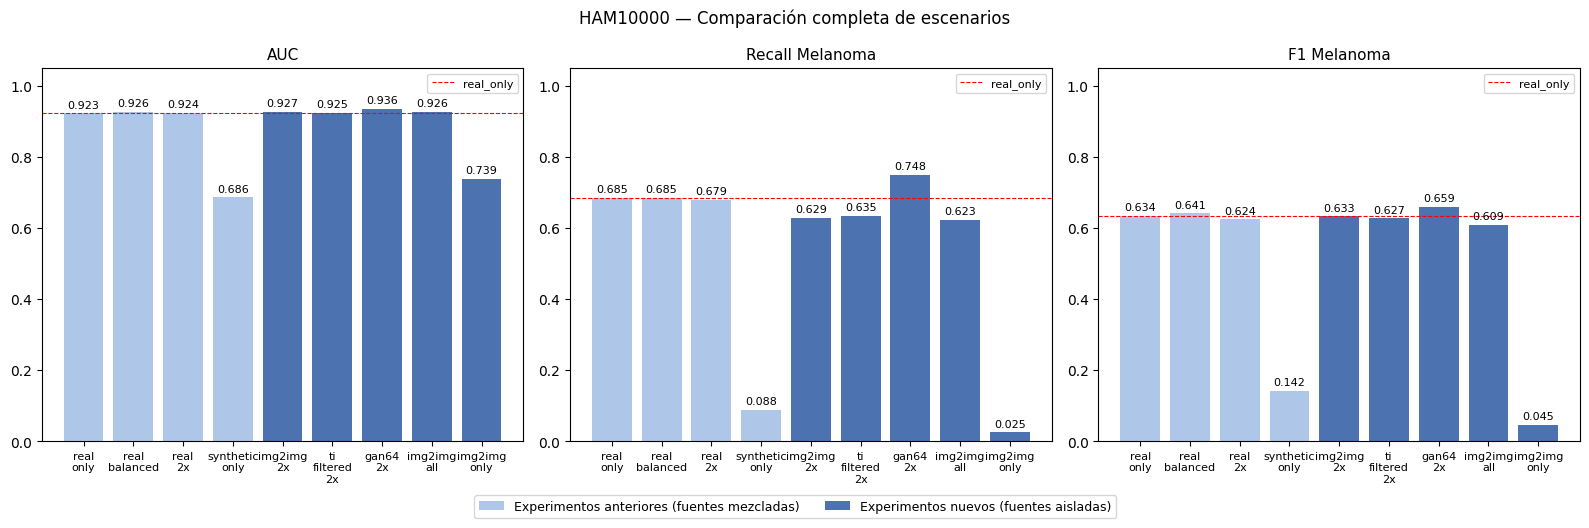

Plot guardado en /content/drive/MyDrive/ham10000-augmentation/experiments/comparison_isolated_plot.png


In [38]:
if len(all_results) >= 2:
    sc_list   = list(all_results.keys())
    metrics_k = [('auc', 'AUC'), ('recall_mel', 'Recall Melanoma'), ('f1_mel', 'F1 Melanoma')]

    # Separar grupo anterior vs nuevo con colores distintos
    old_sc = {'real_only', 'real_balanced', 'real_2x', 'synthetic_only'}
    colors = ['#aec6e8' if sc in old_sc else '#4C72B0' for sc in sc_list]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, (mk, title) in zip(axes, metrics_k):
        vals  = [all_results[sc]['metrics'][mk] for sc in sc_list]
        bars  = ax.bar([s.replace('_', '\n') for s in sc_list], vals, color=colors)
        ax.set_ylim(0, 1.05)
        ax.set_title(title, fontsize=11)
        ax.tick_params(axis='x', labelsize=8)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)
        # Línea baseline real_only
        if 'real_only' in all_results:
            baseline = all_results['real_only']['metrics'][mk]
            ax.axhline(baseline, color='red', linestyle='--', linewidth=0.8, label='real_only')
            ax.legend(fontsize=8)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#aec6e8', label='Experimentos anteriores (fuentes mezcladas)'),
        Patch(facecolor='#4C72B0', label='Experimentos nuevos (fuentes aisladas)'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.05))
    fig.suptitle('HAM10000 — Comparación completa de escenarios', fontsize=12)
    fig.tight_layout()
    out = EXP_ROOT / 'comparison_isolated_plot.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Plot guardado en {out}')